In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [2]:
crop_areas_hw_annual = pd.read_csv('/home/mgurazada/enso_compound_extremes/data/Spatial_extent/growing_season/crop_areas_hw_annual.csv')

pos = crop_areas_hw_annual.columns.get_loc('enso_phase') + 1

# insert the new column
crop_areas_hw_annual.insert(pos, 'season', 'all')

crop_areas_hw_annual.rename(
    columns={'annual_mean_area': 'area_ha'},
    inplace=True
)

crop_areas_hw_annual['mean_area_ha'] = (
    crop_areas_hw_annual
    .groupby(['crop','enso_phase','season'])['area_ha']
    .transform('mean')
)

crop_areas_hw_annual

,crop,enso_phase,season,year_index,area_ha,mean_area_ha
0,maize,el,all,0,1.829423e+07,1.575135e+07
1,maize,el,all,1,1.135403e+07,1.575135e+07
2,maize,el,all,2,1.596174e+07,1.575135e+07
3,maize,el,all,3,8.960523e+06,1.575135e+07
4,maize,el,all,4,2.463813e+07,1.575135e+07
...,...,...,...,...,...,...
842,wheatwinter,ne,all,45,2.312227e+06,1.055113e+07
843,wheatwinter,ne,all,46,2.002007e+06,1.055113e+07
844,wheatwinter,ne,all,47,6.804039e+06,1.055113e+07
845,wheatwinter,ne,all,48,1.221524e+07,1.055113e+07


In [3]:
crop_areas = pd.read_csv('/home/mgurazada/enso_compound_extremes/data/Spatial_extent/crop_areas_by_year_hw1.csv')
crop_areas

,crop,enso_phase,season,year_index,area_ha,mean_area_ha
0,maize,el,jja,0,2.914944e+06,1.677005e+06
1,maize,el,jja,1,5.823284e+05,1.677005e+06
2,maize,el,jja,2,2.185731e+06,1.677005e+06
3,maize,el,jja,3,2.485354e+05,1.677005e+06
4,maize,el,jja,4,4.098502e+06,1.677005e+06
...,...,...,...,...,...,...
5119,wheatwinter,ne,son1,45,2.387838e+05,1.582846e+06
5120,wheatwinter,ne,son1,46,5.047067e+04,1.582846e+06
5121,wheatwinter,ne,son1,47,2.692252e+06,1.582846e+06
5122,wheatwinter,ne,son1,48,2.528479e+06,1.582846e+06


In [4]:
crop_areas1 = pd.concat([crop_areas, crop_areas_hw_annual], ignore_index=True)
crop_areas1

,crop,enso_phase,season,year_index,area_ha,mean_area_ha
0,maize,el,jja,0,2.914944e+06,1.677005e+06
1,maize,el,jja,1,5.823284e+05,1.677005e+06
2,maize,el,jja,2,2.185731e+06,1.677005e+06
3,maize,el,jja,3,2.485354e+05,1.677005e+06
4,maize,el,jja,4,4.098502e+06,1.677005e+06
...,...,...,...,...,...,...
5966,wheatwinter,ne,all,45,2.312227e+06,1.055113e+07
5967,wheatwinter,ne,all,46,2.002007e+06,1.055113e+07
5968,wheatwinter,ne,all,47,6.804039e+06,1.055113e+07
5969,wheatwinter,ne,all,48,1.221524e+07,1.055113e+07


In [5]:
# ENSO years
el_years = [1902, 1904, 1905, 1911, 1913, 1914, 1918, 1923, 1925, 1930, 1939, 1940, 1941, 1957, 1963, 1965, 1968, 1972, 1976, 1977, 1982, 1986, 1987, 1991, 1994, 1997, 2002, 2006, 2009, 2014, 2015, 2018, 2019, 2023]
la_years = [1903, 1908, 1909, 1910, 1916, 1917, 1922, 1924, 1933, 1938, 1942, 1949, 1950, 1954, 1955, 1964, 1967, 1970, 1971, 1973, 1975, 1983, 1984, 1985, 1988, 1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2017, 2020, 2021, 2022, 2024]
ne_years = [1901, 1906, 1907, 1912, 1915, 1919, 1920, 1921, 1926, 1927, 1928, 1929, 1931, 1932, 1934, 1935, 1936, 1937, 1943, 1944, 1945, 1946, 1947, 1948, 1951, 1952, 1953, 1956, 1958, 1959, 1960, 1961, 1962, 1966, 1969, 1974, 1978, 1979, 1980, 1981, 1989, 1990, 1992, 1993, 1996, 2001, 2003, 2004, 2012, 2013, 2016]

# Count unique year_index values per ENSO phase
enso_counts = crop_areas1.groupby("enso_phase")["year_index"].nunique()
print("ENSO year_index counts:\n", enso_counts)

# Count year values you provided
print(f"el: {len(el_years)}, la: {len(la_years)}, ne: {len(ne_years)}")

ENSO year_index counts:
 enso_phase
el    34
la    38
ne    51
Name: year_index, dtype: int64
el: 34, la: 39, ne: 51


In [6]:
# Create a mapping from year_index to actual year for each ENSO phase
enso_year_map = {
    'el': dict(enumerate(el_years, start=0)),
    'la': dict(enumerate(la_years, start=0)),
    'ne': dict(enumerate(ne_years, start=0))
}

# Function to map ENSO year
def get_enso_year(row):
    phase = row['enso_phase']
    index = row['year_index']
    return enso_year_map[phase].get(index, np.nan)

# Apply to DataFrame
crop_areas1['enso_year'] = crop_areas1.apply(get_enso_year, axis=1)

# Preview
crop_areas1.head()

,crop,enso_phase,season,year_index,area_ha,mean_area_ha,enso_year
0,maize,el,jja,0,2.914944e+06,1.677005e+06,1902
1,maize,el,jja,1,5.823284e+05,1.677005e+06,1904
2,maize,el,jja,2,2.185731e+06,1.677005e+06,1905
3,maize,el,jja,3,2.485354e+05,1.677005e+06,1911
4,maize,el,jja,4,4.098502e+06,1.677005e+06,1913


In [7]:
crops_to_keep = ['maize', 'rice', 'soybeans', 'wheat']
crop_areas1 = crop_areas1[crop_areas1['crop'].isin(crops_to_keep)]
crop_areas1[(crop_areas1['crop']=='maize') & (crop_areas1['enso_phase']=='el') & (crop_areas1['season']=='jja')]

,crop,enso_phase,season,year_index,area_ha,mean_area_ha,enso_year
0,maize,el,jja,0,2.914944e+06,1.677005e+06,1902
1,maize,el,jja,1,5.823284e+05,1.677005e+06,1904
2,maize,el,jja,2,2.185731e+06,1.677005e+06,1905
3,maize,el,jja,3,2.485354e+05,1.677005e+06,1911
4,maize,el,jja,4,4.098502e+06,1.677005e+06,1913
5,maize,el,jja,5,1.376274e+06,1.677005e+06,1914
6,maize,el,jja,6,1.071156e+05,1.677005e+06,1918
7,maize,el,jja,7,2.508885e+05,1.677005e+06,1923
8,maize,el,jja,8,1.326973e+06,1.677005e+06,1925
9,maize,el,jja,9,3.388206e+05,1.677005e+06,1930


In [8]:
# Compute crop share
total_cropland_ha = 1710239104
crop_area_ha = {
    'maize': 191679344.0,
    'rice': 129679208.0,
    'soybeans': 124230280.0,
    'wheat': 206507248.0
}
crop_share = {k: v / total_cropland_ha for k, v in crop_area_ha.items()}
crop_areas1['crop_share'] = crop_areas1['crop'].map(crop_share)

# Multiply area exposed by crop share
crop_areas1['weighted_area_ha'] = crop_areas1['area_ha'] * crop_areas1['crop_share']
crop_areas1

/tmp/ipykernel_1715815/2142482931.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crop_areas1['crop_share'] = crop_areas1['crop'].map(crop_share)
/tmp/ipykernel_1715815/2142482931.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crop_areas1['weighted_area_ha'] = crop_areas1['area_ha'] * crop_areas1['crop_share']


,crop,enso_phase,season,year_index,area_ha,mean_area_ha,enso_year,crop_share,weighted_area_ha
0,maize,el,jja,0,2.914944e+06,1.677005e+06,1902,0.112078,3.266997e+05
1,maize,el,jja,1,5.823284e+05,1.677005e+06,1904,0.112078,6.526592e+04
2,maize,el,jja,2,2.185731e+06,1.677005e+06,1905,0.112078,2.449713e+05
3,maize,el,jja,3,2.485354e+05,1.677005e+06,1911,0.112078,2.785523e+04
4,maize,el,jja,4,4.098502e+06,1.677005e+06,1913,0.112078,4.593499e+05
...,...,...,...,...,...,...,...,...,...
5845,wheat,ne,all,45,2.309475e+06,1.055034e+07,2001,0.120748,2.788636e+05
5846,wheat,ne,all,46,2.001026e+06,1.055034e+07,2003,0.120748,2.416190e+05
5847,wheat,ne,all,47,6.804039e+06,1.055034e+07,2004,0.120748,8.215713e+05
5848,wheat,ne,all,48,1.221524e+07,1.055034e+07,2012,0.120748,1.474961e+06


In [9]:
# Group to compute weighted mean area per crop group, ENSO phase, and season
mean_crop_areas = (
    crop_areas1
    .groupby(['crop', 'enso_phase', 'season'])
    .agg(weighted_mean_ha=('weighted_area_ha', 'mean'))
    .reset_index()
)

In [10]:
reshaped_mean_crop_areas = mean_crop_areas.pivot(
    index=['crop', 'season'],
    columns='enso_phase',
    values='weighted_mean_ha'
).reset_index()

# Rename columns
reshaped_mean_crop_areas.columns.name = None
reshaped_mean_crop_areas = reshaped_mean_crop_areas.rename(columns={
    'el': 'mean_area_ha_el',
    'la': 'mean_area_ha_la',
    'ne': 'mean_area_ha_ne'
})

In [11]:
reshaped_mean_crop_areas

,crop,season,mean_area_ha_el,mean_area_ha_la,mean_area_ha_ne
0,maize,all,1.765372e+06,1.033593e+06,1.301475e+06
1,maize,djf,4.482777e+04,3.274674e+04,6.015569e+04
2,maize,jja,1.879546e+05,1.703237e+05,1.193147e+05
3,maize,jja1,2.501034e+05,1.612736e+05,1.228795e+05
4,maize,mam1,2.169332e+05,1.238685e+05,1.696986e+05
5,maize,son,2.046619e+05,1.461220e+05,1.890314e+05
6,maize,son1,2.775470e+05,1.072116e+05,1.788734e+05
7,rice,all,8.557440e+05,4.925410e+05,5.983161e+05
8,rice,djf,5.175892e+04,4.376282e+04,6.519749e+04
9,rice,jja,1.040009e+05,1.088592e+05,9.631853e+04


In [12]:
# Define custom season order
season_order = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1', 'all']
season_cat = pd.CategoricalDtype(categories=season_order, ordered=True)
reshaped_mean_crop_areas['season'] = reshaped_mean_crop_areas['season'].astype(season_cat)
reshaped_mean_crop_areas = reshaped_mean_crop_areas.sort_values(['crop', 'season']).reset_index(drop=True)

In [13]:
reshaped_mean_crop_areas['el_minus_ne'] = (
    (reshaped_mean_crop_areas['mean_area_ha_el'] - reshaped_mean_crop_areas['mean_area_ha_ne']) * 100
) / reshaped_mean_crop_areas['mean_area_ha_ne']

reshaped_mean_crop_areas['la_minus_ne'] = (
    (reshaped_mean_crop_areas['mean_area_ha_la'] - reshaped_mean_crop_areas['mean_area_ha_ne']) * 100
) / reshaped_mean_crop_areas['mean_area_ha_ne']

In [14]:
results = []

for crop in crop_areas1['crop'].unique():
    for season in crop_areas1['season'].unique():
        el = crop_areas1.query("crop == @crop and season == @season and enso_phase == 'el'")['area_ha']
        la = crop_areas1.query("crop == @crop and season == @season and enso_phase == 'la'")['area_ha']
        ne = crop_areas1.query("crop == @crop and season == @season and enso_phase == 'ne'")['area_ha']

        el_p = mannwhitneyu(el, ne, alternative='two-sided', method='auto').pvalue
        la_p = mannwhitneyu(la, ne, alternative='two-sided', method='auto').pvalue

        results.append({
            'crop': crop,
            'season': season,
            'el_pval': el_p,
            'la_pval': la_p
        })

results_df = pd.DataFrame(results)

In [15]:
results_df

,crop,season,el_pval,la_pval
0,maize,jja,0.204325,0.395219
1,maize,son,0.287780,0.514968
2,maize,djf,0.515459,0.112189
3,maize,mam1,0.394183,0.347162
4,maize,jja1,0.045470,0.658380
5,maize,son1,0.463200,0.038136
6,maize,all,0.159148,0.080613
7,rice,jja,0.770637,0.681381
8,rice,son,0.234600,0.983456
9,rice,djf,0.506805,0.386055


In [16]:
def get_star(p):
    return '*' if p < 0.1 else ''

reshaped_mean_crop_areas = reshaped_mean_crop_areas.merge(results_df, on=['crop', 'season'], how='left')
reshaped_mean_crop_areas['el_star'] = reshaped_mean_crop_areas['el_pval'].apply(get_star)
reshaped_mean_crop_areas['la_star'] = reshaped_mean_crop_areas['la_pval'].apply(get_star)

In [17]:
# # Set style
# sns.set(style="whitegrid")

# # Create figure and axes
# fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# # Colorblind-friendly palette
# palette = sns.color_palette("colorblind")

# # --- El Niño - Neutral Plot ---
# sns.barplot(
#     data=reshaped_mean_crop_areas,
#     x='season',
#     y='el_minus_ne',
#     hue='crop',
#     palette=palette,
#     ax=ax[0]
# )
# ax[0].set_title("El Niño - Neutral", fontsize=14)
# ax[0].set_ylabel("Difference in % Area Exposure", fontsize=14)
# ax[0].set_xlabel("Season", fontsize=14)
# ax[0].tick_params(labelsize=14)
# ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
# ax[0].legend(title='Crop', frameon=True, fontsize=13, title_fontsize=14)

# # --- La Niña - Neutral Plot ---
# sns.barplot(
#     data=reshaped_mean_crop_areas,
#     x='season',
#     y='la_minus_ne',
#     hue='crop',
#     palette=palette,
#     ax=ax[1]
# )
# ax[1].set_title("La Niña - Neutral", fontsize=14)
# ax[1].set_ylabel("")  # No duplicate ylabel
# ax[1].set_xlabel("Season", fontsize=14)
# ax[1].tick_params(labelsize=14)
# ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
# ax[1].legend_.remove()  # Hide duplicate legend

# # Title and spacing
# plt.suptitle("%Change in Crop Area Exposure to Hot-Wet Conditions", fontsize=16, y=0.9)
# plt.subplots_adjust(top=0.88)  # Reduce top spacing
# plt.tight_layout(rect=[0, 0, 1, 0.94])  # Adjust layout bounds
# plt.show()

In [18]:
# # Set style
# sns.set(style="whitegrid")

# # Create figure and axes
# fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# # Colorblind-friendly palette
# palette = sns.color_palette("colorblind")

# # Bar plot for El Niño - Neutral
# sns.barplot(
#     data=reshaped_mean_crop_areas,
#     x='season',
#     y='el_minus_ne',
#     hue='crop',
#     palette=palette,
#     ax=ax[0]
# )
# ax[0].set_title("El Niño - Neutral", fontsize=14)
# ax[0].set_ylabel("Difference in % Area Exposure", fontsize=14)
# ax[0].set_xlabel("Season", fontsize=14)
# ax[0].tick_params(labelsize=14)
# ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
# ax[0].legend_.remove()

# # Bar plot for La Niña - Neutral
# sns.barplot(
#     data=reshaped_mean_crop_areas,
#     x='season',
#     y='la_minus_ne',
#     hue='crop',
#     palette=palette,
#     ax=ax[1]
# )
# ax[1].set_title("La Niña - Neutral", fontsize=14)
# ax[1].set_ylabel("")
# ax[1].set_xlabel("Season", fontsize=14)
# ax[1].tick_params(labelsize=14)
# ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
# ax[1].legend_.remove()

# # -----------------------------------------
# # Add significance stars to both subplots
# # -----------------------------------------

# # Loop over each bar group (crop group) and annotate stars
# for i, crop_group in enumerate(reshaped_mean_crop_areas['crop'].unique()):
#     # Filter for the crop group
#     crop_data = reshaped_mean_crop_areas[reshaped_mean_crop_areas['crop'] == crop_group]
    
#     for j, (_, row) in enumerate(crop_data.iterrows()):
#         x_offset = j + i * 0.2 - 0.3  # Adjust bar offset manually (depends on hue spacing)
        
#         # --- El Niño significance star ---
#         if row.get('el_star') == '*':
#             ax[0].text(
#                 x_offset,
#                 row['el_minus_ne'] + 10,
#                 '*',
#                 ha='center', va='bottom',
#                 fontsize=14, color='black'
#             )
        
#         # --- La Niña significance star ---
#         if row.get('la_star') == '*':
#             ax[1].text(
#                 x_offset,
#                 row['la_minus_ne'] + 10,
#                 '*',
#                 ha='center', va='bottom',
#                 fontsize=14, color='black'
#             )

# # Title and layout
# plt.suptitle("Relative change in Crop Area Exposure to Hot-Wet Conditions", fontsize=16, y=0.9)
# plt.tight_layout(rect=[0, 0, 1, 0.94])
# plt.show()


In [19]:
# # Define custom season labels
# season_labels = {
#     'mam': 'MAM(0)',
#     'jja': 'JJA(0)',
#     'son': 'SON(0)',
#     'djf': 'D(0)JF(+1)',
#     'mam1': 'MAM(+1)',
#     'jja1': 'JJA(+1)',
#     'growing season':  'Growing\nseason'
# }

# # Map new labels to a new column
# reshaped_mean_crop_areas['season_label'] = reshaped_mean_crop_areas['season'].map(season_labels)

# # Set style
# sns.set(style="whitegrid")

# # Create figure and axes
# fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# # Colorblind-friendly palette
# palette = sns.color_palette("colorblind")

# # Bar plot for El Niño - Neutral
# sns.barplot(
#     data=reshaped_mean_crop_areas,
#     x='season_label',
#     y='el_minus_ne',
#     hue='crop',
#     palette=palette,
#     ax=ax[0]
# )
# ax[0].set_title("El Niño - Neutral", fontsize=14)
# ax[0].set_ylabel("Difference in % Area Exposure", fontsize=14)
# ax[0].set_xlabel("Season", fontsize=14)
# ax[0].tick_params(labelsize=14)
# ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
# ax[0].legend(title='Crop', frameon=True, fontsize=13, title_fontsize=14)

# # Bar plot for La Niña - Neutral
# sns.barplot(
#     data=reshaped_mean_crop_areas,
#     x='season_label',
#     y='la_minus_ne',
#     hue='crop',
#     palette=palette,
#     ax=ax[1]
# )
# ax[1].set_title("La Niña - Neutral", fontsize=14)
# ax[1].set_ylabel("")
# ax[1].set_xlabel("Season", fontsize=14)
# ax[1].tick_params(labelsize=14)
# ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
# ax[1].legend_.remove()

# # Add significance stars
# for i, crop_group in enumerate(reshaped_mean_crop_areas['crop'].unique()):
#     crop_data = reshaped_mean_crop_areas[reshaped_mean_crop_areas['crop'] == crop_group]
#     for j, (_, row) in enumerate(crop_data.iterrows()):
#         x_offset = j + i * 0.2 - 0.3
#         if row.get('el_star') == '*':
#             ax[0].text(x_offset, row['el_minus_ne'], '*', ha='center', va='bottom', fontsize=14)
#         if row.get('la_star') == '*':
#             ax[1].text(x_offset, row['la_minus_ne'], '*', ha='center', va='bottom', fontsize=14)

# # Title and layout
# plt.suptitle("Relative Change in Crop Area Exposure to Hot-Wet Conditions", fontsize=16, y=0.9)
# plt.tight_layout(rect=[0, 0, 1, 0.94])
# plt.show()

/tmp/ipykernel_1715815/3074678406.py:34: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1715815/3074678406.py:47: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(


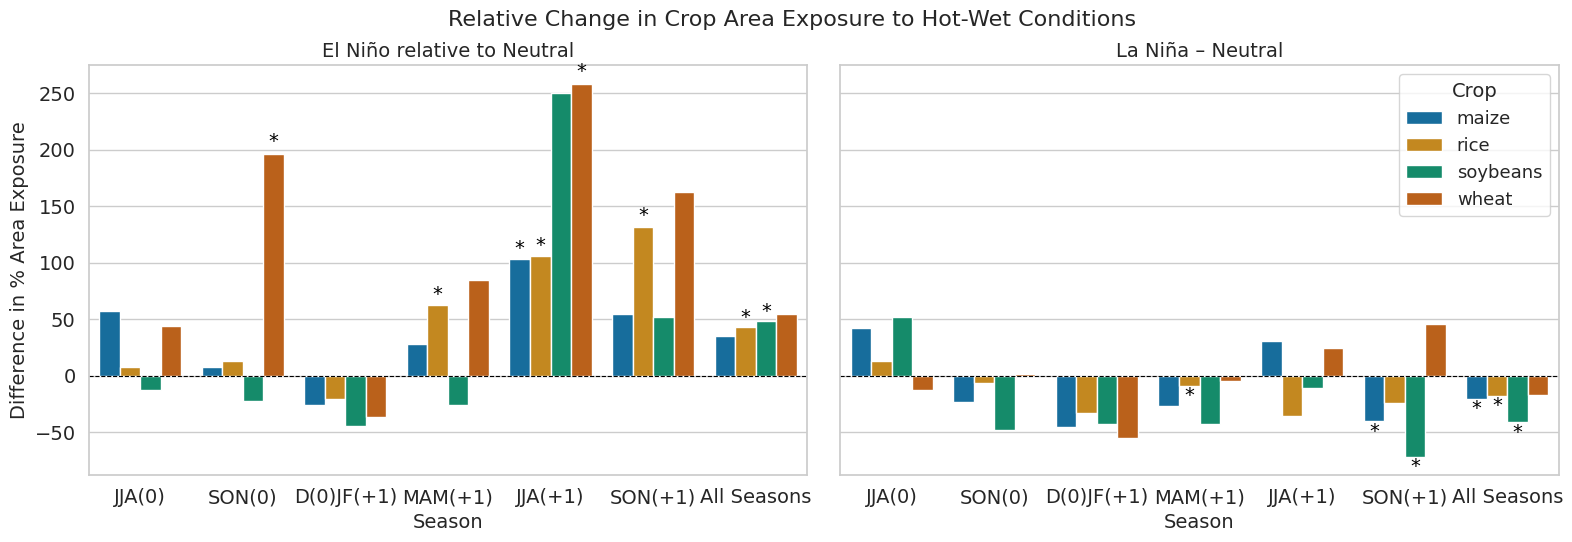

In [20]:
# Define custom season labels
season_labels = {
    'jja': 'JJA(0)',
    'son': 'SON(0)',
    'djf': 'D(0)JF(+1)',
    'mam1':'MAM(+1)',
    'jja1':'JJA(+1)',
    'son1':'SON(+1)',
    'all': 'All Seasons'
    
}

# Map new labels to a new column
reshaped_mean_crop_areas['season_label'] = (
    reshaped_mean_crop_areas['season']
    .map(season_labels)
)

# Build star‐lookup dictionaries
el_star_map = {
    (row.crop, row.season_label): row.el_star
    for _, row in reshaped_mean_crop_areas.iterrows()
}
la_star_map = {
    (row.crop, row.season_label): row.la_star
    for _, row in reshaped_mean_crop_areas.iterrows()
}

sns.set(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
palette = sns.color_palette("colorblind")

# --- EL NIÑO – Neutral ---
sns.barplot(
    data=reshaped_mean_crop_areas,
    x='season_label', y='el_minus_ne',
    hue='crop', palette=palette, ax=ax[0]
)
ax[0].set_title("El Niño relative to Neutral", fontsize=14)
ax[0].set_ylabel("Difference in % Area Exposure", fontsize=14)
ax[0].set_xlabel("Season", fontsize=14)
ax[0].tick_params(labelsize=14)
ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[0].legend_.remove()

# --- LA NIÑA – Neutral ---
sns.barplot(
    data=reshaped_mean_crop_areas,
    x='season_label', y='la_minus_ne',
    hue='crop', palette=palette, ax=ax[1]
)
ax[1].set_title("La Niña – Neutral", fontsize=14)
ax[1].set_ylabel("")
ax[1].set_xlabel("Season", fontsize=14)
ax[1].tick_params(labelsize=14)
ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
ax[1].legend(title='Crop', frameon=True, fontsize=13, title_fontsize=14)


# Function to add significance stars with symmetric 1% offset
def add_significance_stars(axis, star_map, value_col):
    offset_frac = 0.01
    for bar, (_, row) in zip(axis.patches, reshaped_mean_crop_areas.iterrows()):
        star = star_map.get((row.crop, row.season_label), '')
        if not star:
            continue

        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()

        # same fraction above positives and below negatives
        if y >= 0:
            dy = abs(y) * offset_frac
            va = 'bottom'
        else:
            dy = -abs(y) * offset_frac
            va = 'top'

        axis.text(
            x, y + dy, star,
            ha='center', va=va,
            fontsize=14, color='black',
            clip_on=False
        )

# Annotate both panels
add_significance_stars(ax[0], el_star_map, 'el_minus_ne')
add_significance_stars(ax[1], la_star_map, 'la_minus_ne')

# Final title and layout
plt.suptitle(
    "Relative Change in Crop Area Exposure to Hot-Wet Conditions",
    fontsize=16, y=0.90
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

/tmp/ipykernel_1715815/485071098.py:21: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1715815/485071098.py:32: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(


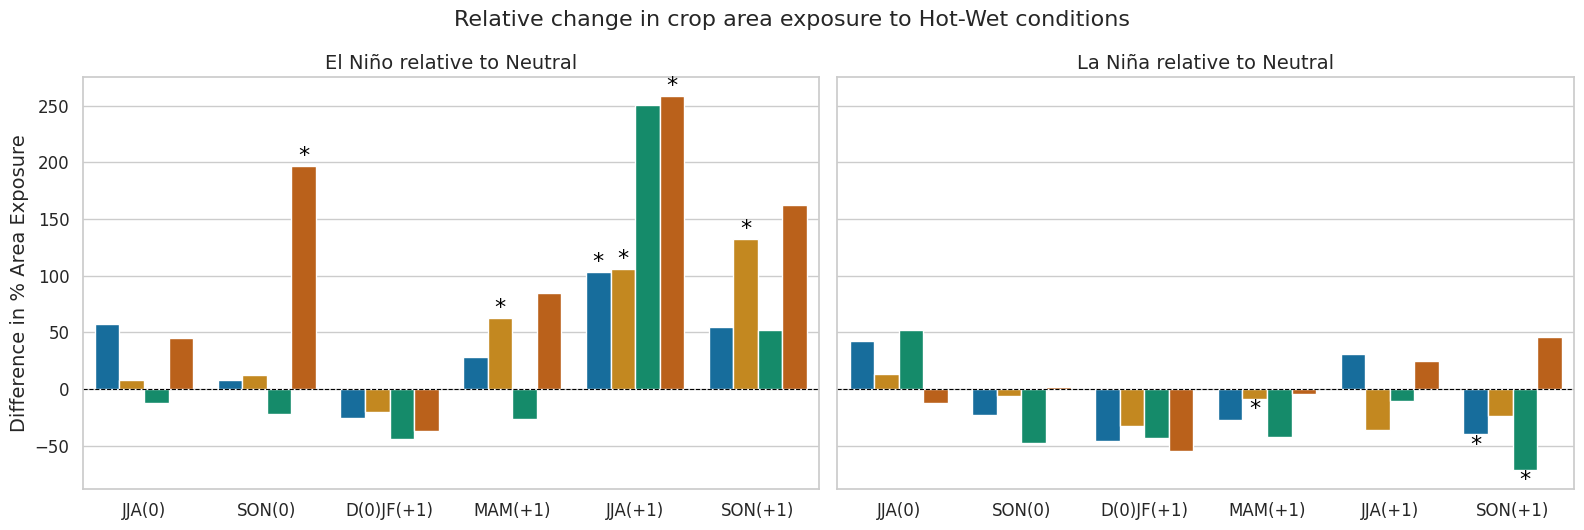

In [31]:
# Keep only "all" season
df = reshaped_mean_crop_areas.loc[reshaped_mean_crop_areas['season'] != 'all'].copy()

# Define custom season labels (only "all" is relevant, but keep dict for safety)
season_labels = {
    'jja': 'JJA(0)', 'son': 'SON(0)', 'djf': 'D(0)JF(+1)',
    'mam1':'MAM(+1)', 'jja1':'JJA(+1)', 'son1':'SON(+1)',
}
df['season_label'] = df['season'].map(season_labels)

# Build star-lookups using the filtered df
el_star_map = {(row.crop, row.season_label): row.el_star for _, row in df.iterrows()}
la_star_map = {(row.crop, row.season_label): row.la_star for _, row in df.iterrows()}

# Plot
sns.set(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
palette = sns.color_palette("colorblind")

# --- EL NIÑO – Neutral ---
sns.barplot(
    data=df, x='season_label', y='el_minus_ne',
    hue='crop', palette=palette, ax=ax[0]
)
ax[0].set_title("El Niño relative to Neutral", fontsize=14)
ax[0].set_ylabel("Difference in % Area Exposure", fontsize=14)
ax[0].set_xlabel("")
ax[0].tick_params(labelsize=12)
ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# --- LA NIÑA – Neutral ---
sns.barplot(
    data=df, x='season_label', y='la_minus_ne',
    hue='crop', palette=palette, ax=ax[1]
)
ax[1].set_title("La Niña relative to Neutral", fontsize=14)
ax[1].set_ylabel("")
ax[1].set_xlabel("")
ax[1].tick_params(labelsize=12)
ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Put a single shared legend above both plots
handles, labels = ax[1].get_legend_handles_labels()
for a in ax: a.legend_.remove()
# fig.legend(handles, labels, title="Crop", ncol=min(4, len(labels)), loc="upper center", frameon=True)

#Add vertical legend to the right of the second panel
# ax[1].legend(
#     handles, labels, title="Crop",
#     loc="upper right", ncol=1,
#     frameon=True, fontsize=14, title_fontsize=14
# )

# Significance stars (use the filtered df to align with bar order)
def add_significance_stars(axis, star_map):
    offset_frac = 0.001
    for bar, (_, row) in zip(axis.patches, df.iterrows()):
        star = star_map.get((row.crop, row.season_label), '')
        if not star:
            continue
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        dy = (abs(y) * offset_frac) * (1 if y >= 0 else -1)
        va = 'bottom' if y >= 0 else 'top'
        axis.text(x, y + dy, star, ha='center', va=va, fontsize=16, color='black', clip_on=False)

add_significance_stars(ax[0], el_star_map)
add_significance_stars(ax[1], la_star_map)

plt.suptitle("Relative change in crop area exposure to Hot-Wet conditions", fontsize=16, y=0.88)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("Fig_S7_C_D.png", dpi=300, bbox_inches="tight")

plt.show()

/tmp/ipykernel_1715815/3950202449.py:22: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1715815/3950202449.py:33: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(


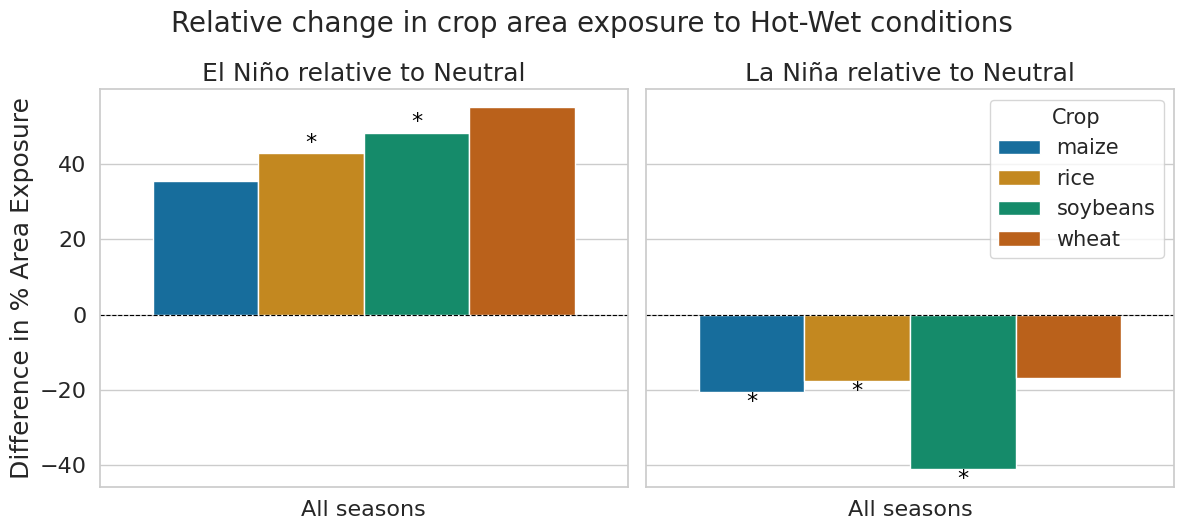

In [32]:
# Keep only "all" season
df = reshaped_mean_crop_areas.loc[reshaped_mean_crop_areas['season'] == 'all'].copy()

# Define custom season labels (only "all" is relevant, but keep dict for safety)
season_labels = {
    'jja': 'JJA(0)', 'son': 'SON(0)', 'djf': 'D(0)JF(+1)',
    'mam1':'MAM(+1)', 'jja1':'JJA(+1)', 'son1':'SON(+1)',
    'all': 'All seasons'
}
df['season_label'] = df['season'].map(season_labels)

# Build star-lookups using the filtered df
el_star_map = {(row.crop, row.season_label): row.el_star for _, row in df.iterrows()}
la_star_map = {(row.crop, row.season_label): row.la_star for _, row in df.iterrows()}

# Plot
sns.set(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
palette = sns.color_palette("colorblind")

# --- EL NIÑO – Neutral ---
sns.barplot(
    data=df, x='season_label', y='el_minus_ne',
    hue='crop', palette=palette, ax=ax[0]
)
ax[0].set_title("El Niño relative to Neutral", fontsize=18)
ax[0].set_ylabel("Difference in % Area Exposure", fontsize=18)
ax[0].set_xlabel("")
ax[0].tick_params(labelsize=16)
ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# --- LA NIÑA – Neutral ---
sns.barplot(
    data=df, x='season_label', y='la_minus_ne',
    hue='crop', palette=palette, ax=ax[1]
)
ax[1].set_title("La Niña relative to Neutral", fontsize=18)
ax[1].set_ylabel("")
ax[1].set_xlabel("")
ax[1].tick_params(labelsize=16)
ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Put a single shared legend above both plots
handles, labels = ax[1].get_legend_handles_labels()
for a in ax: a.legend_.remove()
# fig.legend(handles, labels, title="Crop", ncol=min(4, len(labels)), loc="upper center", frameon=True)

#Add vertical legend to the right of the second panel
ax[1].legend(
    handles, labels, title="Crop",
    loc="upper right", ncol=1,
    frameon=True, fontsize=15, title_fontsize=15
)

# Significance stars (use the filtered df to align with bar order)
def add_significance_stars(axis, star_map):
    offset_frac = 0.001
    for bar, (_, row) in zip(axis.patches, df.iterrows()):
        star = star_map.get((row.crop, row.season_label), '')
        if not star:
            continue
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        dy = (abs(y) * offset_frac) * (1 if y >= 0 else -1)
        va = 'bottom' if y >= 0 else 'top'
        axis.text(x, y + dy, star, ha='center', va=va, fontsize=16, color='black', clip_on=False)

add_significance_stars(ax[0], el_star_map)
add_significance_stars(ax[1], la_star_map)

plt.suptitle("Relative change in crop area exposure to Hot-Wet conditions", fontsize=20, y=0.88)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("Fig_4_C.png", dpi=300, bbox_inches="tight")

plt.show()

In [23]:
crop_pivot = (
    crop_areas1
    .pivot_table(
        index=['crop', 'season'],
        columns='enso_phase',
        values='mean_area_ha'
    )
    .reset_index()
)

# Define the desired season order
season_order = ["jja", "son", "djf", "mam1", "jja1", "son1", "all"]

# Make 'season' a categorical with that order, then sort
crop_pivot['season'] = pd.Categorical(
    crop_pivot['season'],
    categories=season_order,
    ordered=True
)
crop_pivot = crop_pivot.sort_values(['crop', 'season']).reset_index(drop=True)

# Remove the columns name
crop_pivot.columns.name = None

# Preview
print(crop_pivot.head())

    crop season            el            la            ne
0  maize    jja  1.677005e+06  1.519695e+06  1.064573e+06
1  maize    son  1.826075e+06  1.303759e+06  1.686613e+06
2  maize    djf  3.999711e+05  2.921794e+05  5.367329e+05
3  maize   mam1  1.935564e+06  1.105204e+06  1.514119e+06
4  maize   jja1  2.231522e+06  1.438947e+06  1.096380e+06


In [24]:
crop_pivot['el_minus_ne'] = crop_pivot['el'] - crop_pivot['ne']
crop_pivot['la_minus_ne'] = crop_pivot['la'] - crop_pivot['ne']

In [25]:
# # Set style
# sns.set(style="whitegrid")

# # Create figure and axes
# fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# # Colorblind-friendly palette
# palette = sns.color_palette("colorblind")

# # --- El Niño - Neutral Plot ---
# sns.barplot(
#     data=crop_pivot,
#     x='season',
#     y='el_minus_ne',
#     hue='crop',
#     palette=palette,
#     ax=ax[0]
# )
# ax[0].set_title("El Niño - Neutral", fontsize=14)
# ax[0].set_ylabel("Difference in Area Exposure", fontsize=14)
# ax[0].set_xlabel("Season", fontsize=14)
# ax[0].tick_params(labelsize=14)
# ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
# # ax[0].legend(title='Crop', frameon=True, fontsize=13, title_fontsize=14)
# ax[0].legend_.remove()  # Hide duplicate legend
# # --- La Niña - Neutral Plot ---
# sns.barplot(
#     data=crop_pivot,
#     x='season',
#     y='la_minus_ne',
#     hue='crop',
#     palette=palette,
#     ax=ax[1]
# )
# ax[1].set_title("La Niña - Neutral", fontsize=14)
# ax[1].set_ylabel("")  # No duplicate ylabel
# ax[1].set_xlabel("Season", fontsize=14)
# ax[1].tick_params(labelsize=14)
# ax[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
# ax[1].legend(title='Crop', frameon=True, fontsize=13, title_fontsize=14)

# # Title and spacing
# plt.suptitle("Difference in Crop Area Exposure to Hot-Wet Conditions", fontsize=16, y=0.9)
# plt.subplots_adjust(top=0.88)  # Reduce top spacing
# plt.tight_layout(rect=[0, 0, 1, 0.94])  # Adjust layout bounds
# plt.show()

In [26]:
# Add star columns for p < 0.1
signifs = results_df.copy()
signifs['el_star'] = signifs['el_pval'].apply(lambda p: '*' if p < 0.1 else '')
signifs['la_star'] = signifs['la_pval'].apply(lambda p: '*' if p < 0.1 else '')

In [27]:
# # ─────────────────────────────────────────────────────────────────────────────
# # ASSUMPTIONS:
# #  • `crop_pivot` is your DataFrame with
# #      ['crop','season','el_minus_ne','la_minus_ne']
# #  • `signifs` is built as above
# # ─────────────────────────────────────────────────────────────────────────────

# # Build lookup dicts for stars
# el_star_map = {
#     (row.crop, row.season): row.el_star
#     for _, row in signifs.iterrows()
# }
# la_star_map = {
#     (row.crop, row.season): row.la_star
#     for _, row in signifs.iterrows()
# }

# sns.set(style="whitegrid")
# fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
# palette = sns.color_palette("colorblind")

# # ── EL NIÑO – Neutral ─────────────────────────────────────────────────────────
# sns.barplot(
#     data=crop_pivot,
#     x='season',
#     y='el_minus_ne',
#     hue='crop',
#     palette=palette,
#     ax=axes[0]
# )
# axes[0].set_title("El Niño – Neutral", fontsize=16)
# axes[0].set_ylabel("Δ Area Exposure (km²)", fontsize=16)
# axes[0].set_xlabel("Season", fontsize=16)
# axes[0].tick_params(labelsize=14)
# axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
# axes[0].legend_.remove()

# # ── LA NIÑA – Neutral ─────────────────────────────────────────────────────────
# sns.barplot(
#     data=crop_pivot,
#     x='season',
#     y='la_minus_ne',
#     hue='crop',
#     palette=palette,
#     ax=axes[1]
# )
# axes[1].set_title("La Niña – Neutral", fontsize=16)
# axes[1].set_ylabel("")  # no duplicate
# axes[1].set_xlabel("Season", fontsize=16)
# axes[1].tick_params(labelsize=14)
# axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
# # axes[1].legend(title='Crop', frameon=True, fontsize=13, title_fontsize=14)
# axes[1].legend_.remove()

# # ── FUNCTION TO PLACE STARS ──────────────────────────────────────────────────
# def add_significance_stars(ax, star_map, value_col):
#     """
#     ax         : the Axes with the barplot
#     star_map   : dict mapping (crop,season) → '*' or ''
#     value_col  : the column name ('el_minus_ne' or 'la_minus_ne')
#     """
#     for bar, (_, row) in zip(ax.patches, crop_pivot.iterrows()):
#         star = star_map[(row.crop, row.season)]
#         if not star:
#             continue
#         x = bar.get_x() + bar.get_width() / 2
#         y = bar.get_height()
#         # small vertical offset (2% of bar height or 1 if zero)
#         dy = abs(y) * 0.02 if abs(y) > 0 else 1
#         ax.text(
#             x, y + dy,
#             star,
#             ha='center', va='bottom',
#             fontsize=16, color='black'
#         )

# # Annotate both subplots
# add_significance_stars(axes[0], el_star_map, 'el_minus_ne')
# add_significance_stars(axes[1], la_star_map, 'la_minus_ne')

# plt.suptitle("Difference in Crop Area Exposure to Hot‑Wet Conditions", fontsize=16, y=0.88)
# plt.tight_layout(rect=[0, 0, 1, 0.90])
# plt.show()

/tmp/ipykernel_1715815/253399273.py:31: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1715815/253399273.py:44: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(


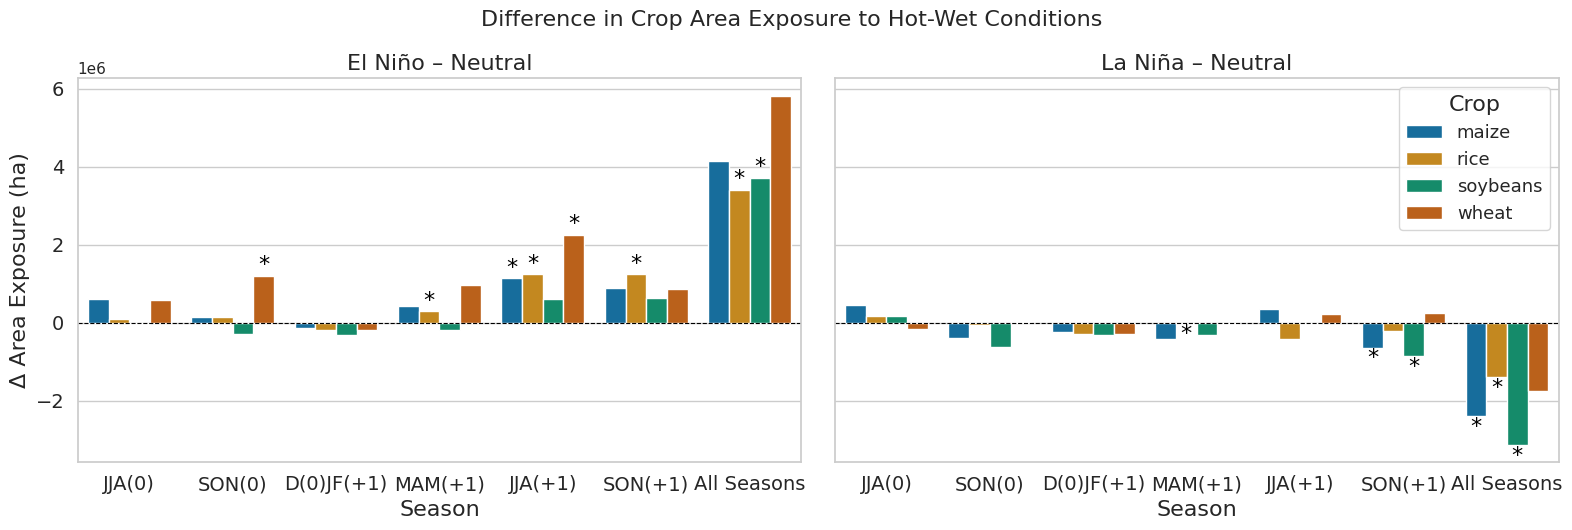

In [28]:
# Define custom season labels
season_labels = {
    'jja': 'JJA(0)',
    'son': 'SON(0)',
    'djf': 'D(0)JF(+1)',
    'mam1':'MAM(+1)',
    'jja1':'JJA(+1)',
    'son1':'SON(+1)',
    'all': 'All Seasons'
    
}

# Map your season codes to the labels
crop_pivot['season_label'] = crop_pivot['season'].map(season_labels)

# Rebuild the star‐lookup dictionaries using the updated labels
el_star_map = {
    (row.crop, season_labels[row.season]): row.el_star
    for _, row in signifs.iterrows()
}
la_star_map = {
    (row.crop, season_labels[row.season]): row.la_star
    for _, row in signifs.iterrows()
}

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
palette = sns.color_palette("colorblind")

# --- EL NIÑO – Neutral ---
sns.barplot(
    data=crop_pivot,
    x='season_label', y='el_minus_ne',
    hue='crop', palette=palette, ax=axes[0]
)
axes[0].set_title("El Niño – Neutral", fontsize=16)
axes[0].set_ylabel("Δ Area Exposure (ha)", fontsize=16)
axes[0].set_xlabel("Season", fontsize=16)
axes[0].tick_params(labelsize=14)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].legend_.remove()

# --- LA NIÑA – Neutral ---
sns.barplot(
    data=crop_pivot,
    x='season_label', y='la_minus_ne',
    hue='crop', palette=palette, ax=axes[1]
)
axes[1].set_title("La Niña – Neutral", fontsize=16)
axes[1].set_ylabel("")
axes[1].set_xlabel("Season", fontsize=16)
axes[1].tick_params(labelsize=14)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].legend(title='Crop', frameon=True, fontsize=13, title_fontsize=16)

# Function to add significance stars with symmetric 2% offset
def add_significance_stars(ax, star_map):
    offset_frac = 0.01
    for bar, (_, row) in zip(ax.patches, crop_pivot.iterrows()):
        star = star_map.get((row.crop, row.season_label), '')
        if not star:
            continue

        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()

        # same fraction of the bar height above or below
        if y >= 0:
            dy = abs(y) * offset_frac
            va = 'bottom'
        else:
            dy = -abs(y) * offset_frac
            va = 'top'

        ax.text(
            x, y + dy, star,
            ha='center', va=va,
            fontsize=16, color='black',
            clip_on=False
        )

# Annotate both plots
add_significance_stars(axes[0], el_star_map)
add_significance_stars(axes[1], la_star_map)

# Final layout
plt.suptitle("Difference in Crop Area Exposure to Hot-Wet Conditions", fontsize=16, y=0.88)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

/tmp/ipykernel_1715815/1534330784.py:30: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1715815/1534330784.py:42: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(


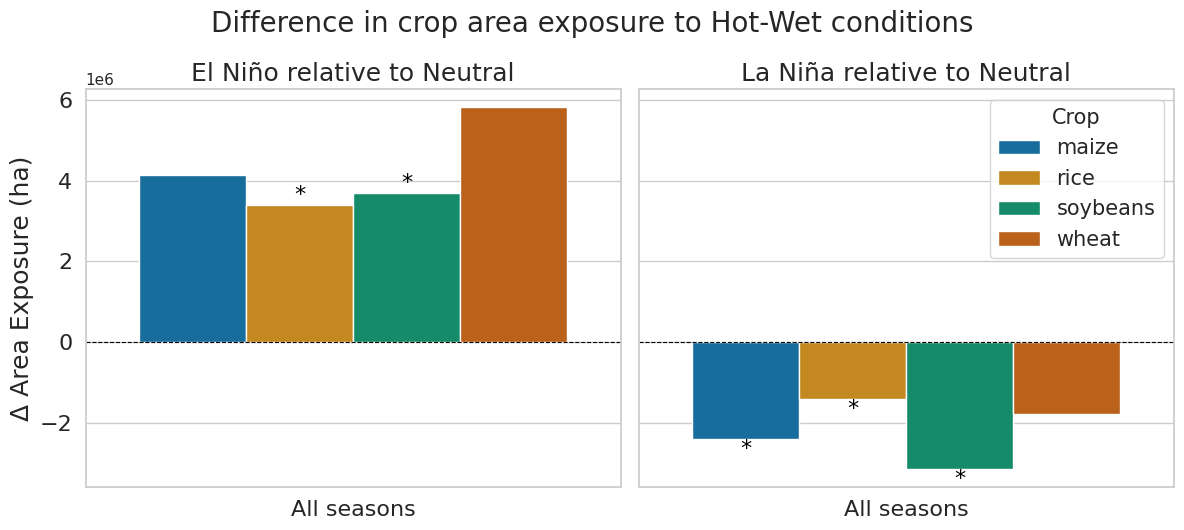

In [33]:
# Add star columns (unchanged)
signifs = results_df.copy()
signifs['el_star'] = signifs['el_pval'].apply(lambda p: '*' if p < 0.1 else '')
signifs['la_star'] = signifs['la_pval'].apply(lambda p: '*' if p < 0.1 else '')

# --- keep ONLY Growing season ---
df_all = crop_pivot.loc[crop_pivot['season'] == 'all'].copy()
signifs_all = signifs.loc[signifs['season'] == 'all'].copy()

# Season labels (map 'all' -> 'Growing season'; others unchanged)
season_labels = {
    'jja': 'JJA(0)', 'son': 'SON(0)', 'djf': 'D(0)JF(+1)',
    'mam1': 'MAM(+1)', 'jja1': 'JJA(+1)', 'son1': 'SON(+1)',
    'all': 'All seasons'
}
df_all['season_label'] = df_all['season'].map(season_labels)

# IMPORTANT: force seaborn to show only the single x category
x_order = ['All seasons']  # prevents extra ticks for unused categories

# Rebuild stars from the filtered table
el_star_map = {(r.crop, season_labels[r.season]): r.el_star for _, r in signifs_all.iterrows()}
la_star_map = {(r.crop, season_labels[r.season]): r.la_star for _, r in signifs_all.iterrows()}

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
palette = sns.color_palette("colorblind")

# --- EL NIÑO – Neutral ---
sns.barplot(
    data=df_all, x='season_label', y='el_minus_ne',
    hue='crop', palette=palette, ax=axes[0], order=x_order
)
axes[0].set_title("El Niño relative to Neutral", fontsize=18)
axes[0].set_ylabel("Δ Area Exposure (ha)", fontsize=18)
axes[0].set_xlabel("")
axes[0].tick_params(labelsize=16)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].legend_.remove()

# --- LA NIÑA – Neutral ---
sns.barplot(
    data=df_all, x='season_label', y='la_minus_ne',
    hue='crop', palette=palette, ax=axes[1], order=x_order
)
axes[1].set_title("La Niña relative to Neutral", fontsize=18)
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].tick_params(labelsize=16)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)

# Legend inside right panel
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend_.remove()
axes[1].legend(handles, labels, title="Crop",
               loc="upper right", ncol=1, frameon=True,
               fontsize=15, title_fontsize=15)

# Stars: skip NaN heights to avoid "posx/posy should be finite" warnings
import numpy as np
def add_significance_stars(axis, star_map, df_for_order):
    offset_frac = 0.001
    for bar, (_, row) in zip(axis.patches, df_for_order.iterrows()):
        star = star_map.get((row.crop, row.season_label), '')
        if not star:
            continue
        y = bar.get_height()
        if not np.isfinite(y):  # nothing plotted for this bar
            continue
        x = bar.get_x() + bar.get_width() / 2
        dy = (abs(y) * offset_frac) * (1 if y >= 0 else -1)
        va = 'bottom' if y >= 0 else 'top'
        axis.text(x, y + dy, star, ha='center', va=va, fontsize=16, color='black', clip_on=False)

add_significance_stars(axes[0], el_star_map, df_all)
add_significance_stars(axes[1], la_star_map, df_all)

plt.suptitle("Difference in crop area exposure to Hot-Wet conditions", fontsize=20, y=0.88)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("Fig_4_B.png", dpi=300, bbox_inches="tight")

plt.show()

/tmp/ipykernel_1715815/1248912141.py:34: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(
/tmp/ipykernel_1715815/1248912141.py:46: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(


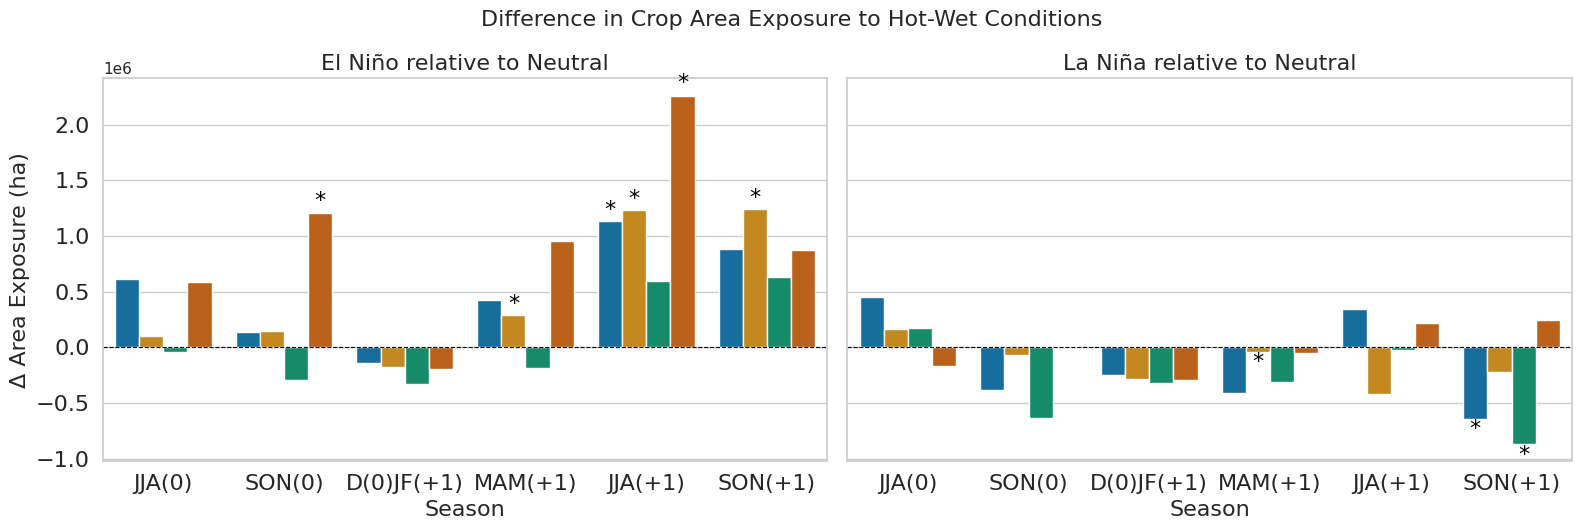

In [34]:
# --- 1) Define custom season labels
season_labels = {
    'jja': 'JJA(0)',
    'son': 'SON(0)',
    'djf': 'D(0)JF(+1)',
    'mam1': 'MAM(+1)',
    'jja1': 'JJA(+1)',
    'son1': 'SON(+1)',
}

# --- 2) Filter out "all"
crop_pivot_noall = crop_pivot.loc[crop_pivot['season'] != 'all'].copy()
signifs_noall    = signifs.loc[signifs['season'] != 'all'].copy()

# Map labels
crop_pivot_noall['season_label'] = crop_pivot_noall['season'].map(season_labels)

# --- 3) Build star maps
el_star_map = {
    (row.crop, season_labels[row.season]): row.el_star
    for _, row in signifs_noall.iterrows()
}
la_star_map = {
    (row.crop, season_labels[row.season]): row.la_star
    for _, row in signifs_noall.iterrows()
}

# --- 4) Plot
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
palette = sns.color_palette("colorblind")

# El Niño
sns.barplot(
    data=crop_pivot_noall, x='season_label', y='el_minus_ne',
    hue='crop', palette=palette, ax=axes[0]
)
axes[0].set_title("El Niño relative to Neutral", fontsize=16)
axes[0].set_ylabel("Δ Area Exposure (ha)", fontsize=16)
axes[0].set_xlabel("Season", fontsize=16)
axes[0].tick_params(labelsize=16)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].legend_.remove()

# La Niña
sns.barplot(
    data=crop_pivot_noall, x='season_label', y='la_minus_ne',
    hue='crop', palette=palette, ax=axes[1]
)
axes[1].set_title("La Niña relative to Neutral", fontsize=16)
axes[1].set_ylabel("")
axes[1].set_xlabel("Season", fontsize=16)
axes[1].tick_params(labelsize=16)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].legend_.remove()

# --- 5) Annotate stars
def add_significance_stars(ax, star_map, df):
    offset_frac = 0.01
    for bar, (_, row) in zip(ax.patches, df.iterrows()):
        star = star_map.get((row.crop, row.season_label), '')
        if not star:
            continue
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        dy = abs(y) * offset_frac if y >= 0 else -abs(y) * offset_frac
        va = 'bottom' if y >= 0 else 'top'
        ax.text(x, y + dy, star, ha='center', va=va,
                fontsize=16, color='black', clip_on=False)

add_significance_stars(axes[0], el_star_map, crop_pivot_noall)
add_significance_stars(axes[1], la_star_map, crop_pivot_noall)

# --- 6) Final layout
plt.suptitle("Difference in Crop Area Exposure to Hot-Wet Conditions", fontsize=16, y=0.88)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("Fig_S6_C_D.png", dpi=300, bbox_inches="tight")

plt.show()